In [1]:
import os
import clip
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = "cuda"

# --- Load CLIP ---
print("Loading CLIP model...")
model, preprocess = clip.load("ViT-L/14", device=device)
model.eval()
print(f"Using: {torch.cuda.get_device_name(0)}") 

Loading CLIP model...
Using: NVIDIA RTX A6000


In [3]:
import os

base_path = "/data/b23_himanshu_shekhar/LFF/Noise_lff/datasets/bffhq/5pct"

class_0_path = os.path.join(base_path, "0")
class_1_path = os.path.join(base_path, "1")

len_0 = len(os.listdir(class_0_path))
len_1 = len(os.listdir(class_1_path))

print("Length of 5pct/0:", len_0)
print("Length of 5pct/1:", len_1)

Length of 5pct/0: 9600
Length of 5pct/1: 9600


In [4]:
# --- Dataset for flat folders (test/valid) ---
class BFFHQFlat(Dataset):
    def __init__(self, folder, transform):
        self.transform = transform
        self.samples = []
        for fname in sorted(os.listdir(folder)):
            if not fname.endswith(".png"):
                continue
            parts = fname.replace(".png", "").split("_")
            age    = int(parts[1])   # 0=young, 1=old    
            gender = int(parts[2])   # 0=female, 1=male
            self.samples.append((os.path.join(folder, fname), age, gender))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age, gender = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, age, gender

# --- Dataset for 0/1 folders (train) ---
class BFFHQTrain(Dataset):
    def __init__(self, folder, transform):
        self.transform = transform
        self.samples = []
        for age_label in ["0", "1"]:          # 0=old, 1=young
            subdir = os.path.join(folder, age_label)
            if not os.path.exists(subdir):
                continue
            for fname in sorted(os.listdir(subdir)):
                if not fname.endswith(".png"):
                    continue
                parts = fname.replace(".png", "").split("_")
                age    = int(parts[1])   # from filename: 0=young, 1=old
                gender = int(parts[2])   # 0=female, 1=male
                path   = os.path.join(subdir, fname)
                self.samples.append((path, age, gender))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age, gender = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, age, gender

In [6]:
# --- Single extraction function (works for both) ---
def extract(loader):
    all_embs, all_age, all_gender = [], [], []
    with torch.no_grad():
        for imgs, age, gender in loader:
            embs = model.encode_image(imgs.to(device))
            all_embs.append(embs.cpu())
            all_age.append(age)
            all_gender.append(gender)
    return torch.cat(all_embs), torch.cat(all_age).numpy(), torch.cat(all_gender).numpy()


# --- Run extraction ---
base = "/data/b23_himanshu_shekhar/LFF/Noise_lff/datasets/bffhq"

print("Extracting test...")
test_ds = BFFHQFlat(f"{base}/test", preprocess)
test_embs, test_age, test_gender = extract(DataLoader(test_ds, batch_size=512, num_workers=4))

print("Extracting valid...")
valid_ds = BFFHQFlat(f"{base}/valid", preprocess)
valid_embs, valid_age, valid_gender = extract(DataLoader(valid_ds, batch_size=512, num_workers=4))

print("Extracting train (5pct)...")
train_ds = BFFHQTrain(f"{base}/5pct", preprocess)
train_embs, train_age, train_gender = extract(DataLoader(train_ds, batch_size=512, num_workers=4))

# --- Extract 0(young) and 1(old) separately ---
print("Extracting train 0(young) (5pct)...")
young_0_embs, young_0_age, young_0_gender = extract(DataLoader(
    BFFHQFlat(f"{base}/5pct/0", preprocess),
    batch_size=512, num_workers=4))

print("Extracting train 1(old) (5pct)...")
old_1_embs, old_1_age, old_1_gender = extract(DataLoader(
    BFFHQFlat(f"{base}/5pct/1", preprocess),
    batch_size=512, num_workers=4))

Extracting test...
Extracting valid...
Extracting train (5pct)...
Extracting train 0(young) (5pct)...
Extracting train 1(old) (5pct)...


In [7]:
# --- Save ---
os.makedirs("5pct/embeddings", exist_ok=True)

# test / valid
torch.save(test_embs,  "5pct/embeddings/test_embs.pt")
torch.save(valid_embs, "5pct/embeddings/valid_embs.pt")
np.save("5pct/embeddings/test_age.npy",     test_age)
np.save("5pct/embeddings/test_gender.npy",  test_gender)
np.save("5pct/embeddings/valid_age.npy",    valid_age)
np.save("5pct/embeddings/valid_gender.npy", valid_gender)

# train combined
torch.save(train_embs, "5pct/embeddings/train_embs.pt")
np.save("5pct/embeddings/train_age.npy",    train_age)
np.save("5pct/embeddings/train_gender.npy", train_gender)



torch.save(young_0_embs,    "5pct/embeddings/young_0_embs.pt")
torch.save(old_1_embs, "5pct/embeddings/old_1_embs.pt")
np.save("5pct/embeddings/young_0_age.npy",       young_0_age)
np.save("5pct/embeddings/young_0_gender.npy",    young_0_gender)
np.save("5pct/embeddings/old_1_age.npy",    old_1_age)
np.save("5pct/embeddings/old_1_gender.npy", old_1_gender)

# align / conflict separately
# torch.save(align_embs,    "embeddings/5pct/align_embs.pt")
# torch.save(conflict_embs, "embeddings/5pct/conflict_embs.pt")
# np.save("embeddings/5pct/align_age.npy",       align_age)
# np.save("embeddings/5pct/align_gender.npy",    align_gender)
# np.save("embeddings/5pct/conflict_age.npy",    conflict_age)
# np.save("embeddings/5pct/conflict_gender.npy", conflict_gender)


print("All embeddings saved to embeddings/")

All embeddings saved to embeddings/


In [8]:
# --- Bias check ---
print("\n--- Bias check ---")
for split, age_l, gen_l in [
    ("test",     test_age,     test_gender),
    ("valid",    valid_age,    valid_gender),
    ("train",    train_age,    train_gender),
    # ("align",    align_age,    align_gender),
    # ("conflict", conflict_age, conflict_gender)
     ("young",    young_0_age,    young_0_gender),
    ("old", old_1_age, old_1_gender)
]:
    print(f"\n{split} (n={len(age_l)}):")
    for age, name in [(0, "young"), (1, "old")]:
        mask = age_l == age
        if mask.sum() == 0:
            continue
        male_pct = (gen_l[mask] == 1).mean() * 100
        print(f"  {name}: {male_pct:.1f}% male, {100-male_pct:.1f}% female  (n={mask.sum()})")


--- Bias check ---

test (n=1000):
  young: 50.0% male, 50.0% female  (n=500)
  old: 50.0% male, 50.0% female  (n=500)

valid (n=1000):
  young: 0.0% male, 100.0% female  (n=500)
  old: 100.0% male, 0.0% female  (n=500)

train (n=19200):
  young: 2.0% male, 98.0% female  (n=9600)
  old: 98.0% male, 2.0% female  (n=9600)

young (n=9600):
  young: 2.0% male, 98.0% female  (n=9600)

old (n=9600):
  old: 98.0% male, 2.0% female  (n=9600)


In [8]:
import torch
import numpy as np

# Load
train_embs  = torch.load("5pct/embeddings/train_embs.pt").float()
test_embs   = torch.load("5pct/embeddings/test_embs.pt").float()
valid_embs  = torch.load("5pct/embeddings/valid_embs.pt").float()
# align_embs  = torch.load("embeddings/align_embs.pt").float()
# conflict_embs = torch.load("embeddings/conflict_embs.pt").float()
young_0_embs=torch.load("5pct/embeddings/young_0_embs.pt").float()
old_1_embs=torch.load("5pct/embeddings/old_1_embs.pt").float()


young_0_age=np.load("5pct/embeddings/young_0_age.npy")
young_0_gender=np.load("5pct/embeddings/young_0_gender.npy")
old_1_age=np.load("5pct/embeddings/old_1_age.npy")
old_1_gender=np.load("5pct/embeddings/old_1_gender.npy")
train_age     = np.load("5pct/embeddings/train_age.npy")
train_gender  = np.load("5pct/embeddings/train_gender.npy")
test_age      = np.load("5pct/embeddings/test_age.npy")
test_gender   = np.load("5pct/embeddings/test_gender.npy")
valid_age     = np.load("5pct/embeddings/valid_age.npy")
valid_gender  = np.load("5pct/embeddings/valid_gender.npy")
# align_age     = np.load("5pct/embeddings/align_age.npy")
# align_gender  = np.load("5pct/embeddings/align_gender.npy")
# conflict_age  = np.load("5pct/embeddings/conflict_age.npy")
# conflict_gender = np.load("5pct/embeddings/conflict_gender.npy")

In [9]:
print(train_embs.shape)
print(test_embs.shape)
print(valid_embs.shape)
# print(align_embs.shape)
# print(conflict_embs.shape)
print(young_0_embs.shape)
print(old_1_embs.shape)

torch.Size([19200, 768])
torch.Size([1000, 768])
torch.Size([1000, 768])
torch.Size([9600, 768])
torch.Size([9600, 768])


In [10]:
print(train_embs[(train_age==1) & (train_gender==1)][0].shape)

torch.Size([768])


In [11]:
# Mean vectors per group (more stable than single samples)
old_male    = train_embs[(train_age==1) & (train_gender==1)].mean(0)
old_female  = train_embs[(train_age==1) & (train_gender==0)].mean(0)
young_male  = train_embs[(train_age==0) & (train_gender==1)].mean(0)
young_female= train_embs[(train_age==0) & (train_gender==0)].mean(0)

def find_nearest(query_vec, embs, age_l, gender_l, top_k=5):
    query_norm = query_vec / query_vec.norm()
    embs_norm  = embs 
    sims       = embs_norm @ query_norm
    topk       = sims.topk(top_k)
    print(f"Top {top_k} nearest:")
    for sim, idx in zip(topk.values, topk.indices):
        a = "old"   if age_l[idx]==1    else "young"
        g = "male"  if gender_l[idx]==1 else "female"
        print(f"  idx={idx.item():5d}  {a} {g:8s}  sim={sim:.3f}")

# --- Try different arithmetic ---

# 1. old male - gender = old female?
print("\n1. old_male - (male - female):")
find_nearest(old_male - (young_male - young_female), train_embs, train_age, train_gender)

# 2. young female + age = old female?
print("\n2. young_female + (old - young):")
find_nearest(young_female + (old_male - young_male), train_embs, train_age, train_gender)

# 3. young male + age = old male?
print("\n3. young_male + (old - young):")
find_nearest(young_male + (old_female - young_female), train_embs, train_age, train_gender)


1. old_male - (male - female):
Top 5 nearest:
  idx= 2814  young female    sim=18.031
  idx= 3240  young female    sim=18.026
  idx= 9070  young female    sim=17.942
  idx= 2796  young female    sim=17.876
  idx= 8567  young female    sim=17.867

2. young_female + (old - young):
Top 5 nearest:
  idx= 2814  young female    sim=18.031
  idx= 3240  young female    sim=18.026
  idx= 9070  young female    sim=17.942
  idx= 2796  young female    sim=17.876
  idx= 8567  young female    sim=17.867

3. young_male + (old - young):
Top 5 nearest:
  idx=12558  old male      sim=18.925
  idx=18263  old male      sim=18.703
  idx=12865  old male      sim=18.578
  idx= 7109  young male      sim=18.526
  idx=19137  old male      sim=18.515


In [12]:
# How far apart are the 4 group mean vectors?
import torch.nn.functional as F

groups = {
    "old_male":    old_male,
    "old_female":  old_female,
    "young_male":  young_male,
    "young_female":young_female,
}

print("Pairwise cosine similarities between group means:")
print(f"{'':15s}", end="")
for n in groups: print(f"{n:15s}", end="")
print()

for n1, v1 in groups.items():
    print(f"{n1:15s}", end="")
    for n2, v2 in groups.items():
        sim = F.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item()
        print(f"{sim:15.3f}", end="")
    print()

Pairwise cosine similarities between group means:
               old_male       old_female     young_male     young_female   
old_male                 1.000          0.894          0.914          0.861
old_female               0.894          1.000          0.862          0.926
young_male               0.914          0.862          1.000          0.921
young_female             0.861          0.926          0.921          1.000


In [13]:
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt
    import numpy as np
    import os
    os.makedirs("5pct/tsne", exist_ok=True)

    group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
    colors      = {0: "#E84393",      1: "#1A5FA8",    2: "#FF8C00",    3: "#2ECC71"}

    splits = [
        ("train",    train_embs.numpy(),    train_age,    train_gender),
        ("test",     test_embs.numpy(),     test_age,     test_gender),
        ("valid",    valid_embs.numpy(),    valid_age,    valid_gender),
        # ("align",    align_embs.numpy(),    align_age,    align_gender),
        # ("conflict", conflict_embs.numpy(), conflict_age, conflict_gender),
        ("young_0_embs",    young_0_embs.numpy(),    young_0_age,    young_0_gender),
        ("old_1_embs", old_1_embs.numpy(), old_1_age, old_1_gender)
    ]

    for split_name, embs, age, gender in splits:
        np.random.seed(42)
        n=len(embs)
        idx = np.random.choice(len(embs), n, replace=False)
        embs_sub   = embs[idx]
        age_sub    = age[idx]
        gender_sub = gender[idx]
        group_sub  = age_sub * 2 + gender_sub

        print(f"Running t-SNE for {split_name} ({n} points)...")
        tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
        e2d  = tsne.fit_transform(embs_sub)

        plt.figure(figsize=(7, 6))
        for g, gname in group_names.items():
            mask = group_sub == g
            if mask.sum() == 0:
                continue
            plt.scatter(e2d[mask, 0], e2d[mask, 1],
                        c=colors[g], label=gname, s=15, alpha=0.7)

        plt.title(f"t-SNE — {split_name} (n={n})", fontsize=13)
        plt.legend(fontsize=9, markerscale=2)
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(f"5pct/tsne/tsne_{split_name}.png", dpi=150, bbox_inches="tight")
        plt.close()
        print(f"Saved tsne_{split_name}.png")

    print("\nAll plots saved!")

Running t-SNE for train (19200 points)...
Saved tsne_train.png
Running t-SNE for test (1000 points)...
Saved tsne_test.png
Running t-SNE for valid (1000 points)...
Saved tsne_valid.png
Running t-SNE for young_0_embs (9600 points)...
Saved tsne_young_0_embs.png
Running t-SNE for old_1_embs (9600 points)...
Saved tsne_old_1_embs.png

All plots saved!


# Debiasing Embeddings

In [14]:
# Check how spread out each group is
for (a, g, name) in [(1,1,"old male"), (1,0,"old female"), 
                      (0,1,"young male"), (0,0,"young female")]:
    mask = (train_age==a) & (train_gender==g)
    group = train_embs[mask]
    print(f"{name:15s}  n={mask.sum():5d}  "
          f"mean_norm={group.norm(dim=-1).mean():.3f}  "
          f"intra_sim={( (group/group.norm(dim=-1,keepdim=True)) @ (group/group.norm(dim=-1,keepdim=True)).T ).mean():.3f}")

old male         n= 9120  mean_norm=18.256  intra_sim=0.606
old female       n=  480  mean_norm=18.792  intra_sim=0.701
young male       n=  480  mean_norm=19.335  intra_sim=0.688
young female     n= 9120  mean_norm=19.364  intra_sim=0.688


In [15]:
# # Step 1 — Build bipartite similarity graph
# import torch
# import numpy as np

# # Normalize embeddings
# align_norm    = align_embs    / align_embs.norm(dim=-1, keepdim=True)
# conflict_norm = conflict_embs / conflict_embs.norm(dim=-1, keepdim=True)

# # Similarity matrix between ALL align and conflict samples
# # shape: (19008, 192)
# sim_matrix = align_norm @ conflict_norm.T
# print(f"Similarity matrix shape: {sim_matrix.shape}")
# print(f"Mean similarity: {sim_matrix.mean():.3f}")
# print(f"Max similarity:  {sim_matrix.max():.3f}")



# # Step 2 — Find cross-class pairs (align class X ↔ conflict class Y)
# # young_female(align) ↔ old_female(conflict)
# yf_align_idx    = np.where((align_age==0) & (align_gender==0))[0]  # young female align
# of_conflict_idx = np.where((conflict_age==1) & (conflict_gender==0))[0]  # old female conflict

# sim_yf_of = sim_matrix[np.ix_(yf_align_idx, of_conflict_idx)]
# print(f"\nyoung_female(align) ↔ old_female(conflict)")
# print(f"  shape: {sim_yf_of.shape}")
# print(f"  mean sim: {sim_yf_of.mean():.3f}")
# print(f"  max sim:  {sim_yf_of.max():.3f}")

# # old_male(align) ↔ young_male(conflict)
# om_align_idx    = np.where((align_age==1) & (align_gender==1))[0]
# ym_conflict_idx = np.where((conflict_age==0) & (conflict_gender==1))[0]

# sim_om_ym = sim_matrix[np.ix_(om_align_idx, ym_conflict_idx)]
# print(f"\nold_male(align) ↔ young_male(conflict)")
# print(f"  shape: {sim_om_ym.shape}")
# print(f"  mean sim: {sim_om_ym.mean():.3f}")
# print(f"  max sim:  {sim_om_ym.max():.3f}")


# # young_female(align) ↔ young_male(conflict of same class)
# yf_align_idx    = np.where((align_age==0) & (align_gender==0))[0]
# ym_conflict_idx = np.where((conflict_age==0) & (conflict_gender==1))[0]

# sim_om_ym = sim_matrix[np.ix_(yf_align_idx, ym_conflict_idx)]
# print(f"young_female(align) ↔ young_male(conflict of same class)")
# print(f"  shape: {sim_om_ym.shape}")
# print(f"  mean sim: {sim_om_ym.mean():.3f}")
# print(f"  max sim:  {sim_om_ym.max():.3f}")


# # old_female(align) ↔ old_male(conflict of same class)
# om_align_idx    = np.where((align_age==1) & (align_gender==1))[0]
# of_conflict_idx = np.where((conflict_age==1) & (conflict_gender==0))[0]

# sim_om_ym = sim_matrix[np.ix_(om_align_idx, of_conflict_idx)]
# print(f"old_female(align) ↔ old_male(conflict of same class)")
# print(f"  shape: {sim_om_ym.shape}")
# print(f"  mean sim: {sim_om_ym.mean():.3f}")
# print(f"  max sim:  {sim_om_ym.max():.3f}")

## Similarity Threshold = 0.8

In [16]:
import time

# Load age-based embeddings

old_embs   = old_1_embs   # all old (male+female)
young_embs = young_0_embs   # all young (male+female)

print(f"old:   {old_embs.shape}")
print(f"young: {young_embs.shape}")

# Normalize
old_norm   = old_embs   / old_embs.norm(dim=-1, keepdim=True)
young_norm = young_embs / young_embs.norm(dim=-1, keepdim=True)

start=time.time()
# Similarity matrix old↔young (9600 x 9600)
print("Computing similarity matrix...")
sim_matrix = old_norm @ young_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.80  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end=time.time()
print((end-start)/60,"minutes")

old:   torch.Size([9600, 768])
young: torch.Size([9600, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([9600, 9600])
mean=0.560  max=0.941  min=0.102

Pairs with sim > 0.8: 238738
sim range: 0.800 - 0.941
mean sim of selected pairs: 0.822
0.006912140051523844 minutes


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("5pct/Projection_heads", exist_ok=True)

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

start=time.time()
print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/Projection_heads/projection_head(0.8).pt")
end = time.time()
print((end-start)/60,"minutes")

Building pairs from 238738 high-sim old↔young pairs...
e1s shape:   torch.Size([238738, 768])
e2s shape:   torch.Size([238738, 768])
weights:     min=0.800  max=0.941
Before training: mean_sim=0.822  std=0.015
Training...
  epoch   0  loss=0.0206  mean_sim=0.058  std=0.028
  epoch  10  loss=0.0000  mean_sim=0.062  std=0.029
  epoch  20  loss=0.0000  mean_sim=-0.014  std=0.027
  epoch  30  loss=0.0000  mean_sim=-0.047  std=0.023
  epoch  40  loss=0.0000  mean_sim=-0.109  std=0.020
Done!
3.3542872786521913 minutes


In [18]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.8: {(sim_before_flat>0.8).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.8: {(sim_after_flat>0.8).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.560  std=0.100  max=0.941  >0.8: 238738
  AFTER:  mean=-0.331  std=0.207  max=0.924  >0.8: 1182

W_diff from identity: 0.00182


In [19]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/embeddings/train_proj(0.8).pt")
torch.save(test_proj,  "5pct/embeddings/test_proj(0.8).pt")
torch.save(valid_proj, "5pct/embeddings/valid_proj(0.8).pt")
print("Saved!")

Saved!


In [20]:
train_proj=torch.load("5pct/embeddings/train_proj(0.8).pt")
test_proj=torch.load("5pct/embeddings/test_proj(0.8).pt")
valid_proj=torch.load("5pct/embeddings/valid_proj(0.8).pt")

In [21]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 96.4%
  young female  : 100.0%
  young male    : 94.4%
  old female  : 92.0%
  old male    : 99.2%
  worst: 92.0%  best: 100.0%  gap: 8.0%

  DEBIASED (linear push)
Overall accuracy: 95.9%
  young female  : 100.0%
  young male    : 93.6%
  old female  : 90.4%
  old male    : 99.6%
  worst: 90.4%  best: 100.0%  gap: 9.6%


Running t-SNE for train (proj) (19200 points)...
Running t-SNE for test (proj) (1000 points)...
Running t-SNE for valid (proj) (1000 points)...
Running t-SNE for old (proj) (9600 points)...
Running t-SNE for young (proj) (9600 points)...
Saved!


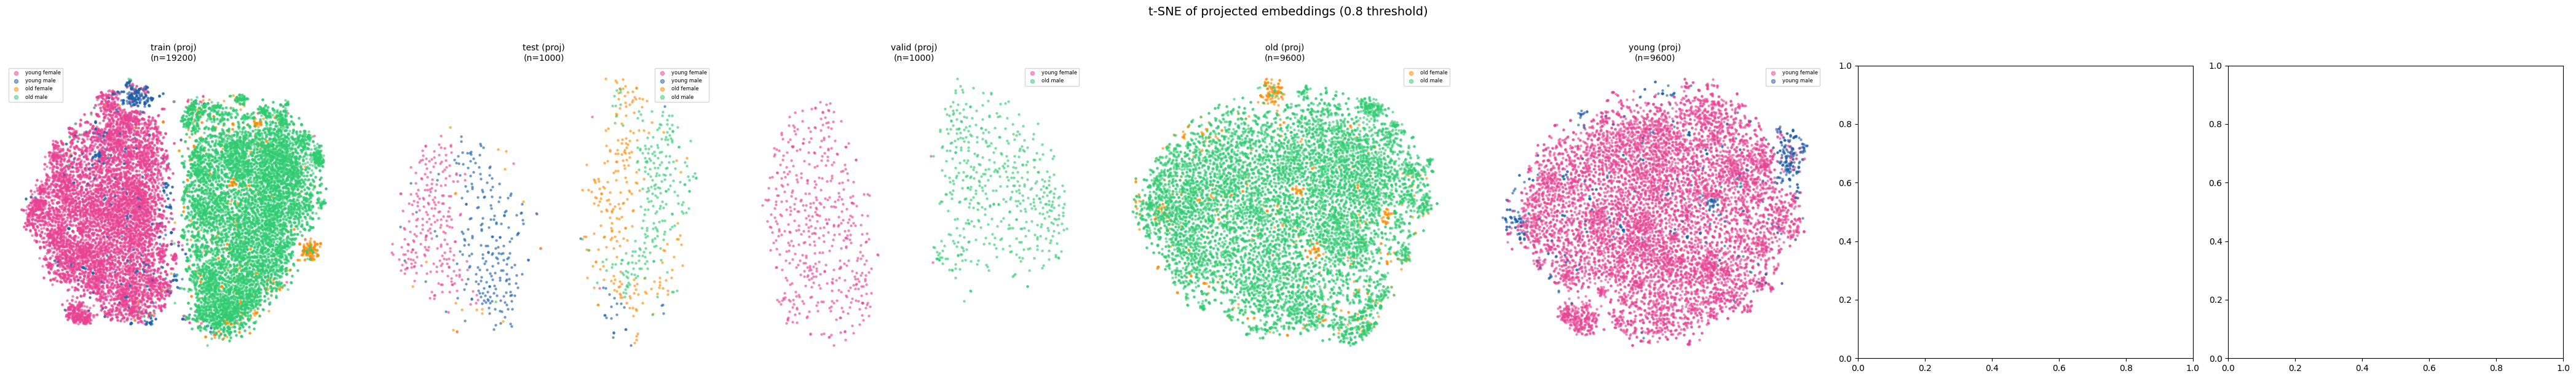

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",    project(train_embs),    train_age,    train_gender),
    ("test (proj)",     project(test_embs),      test_age,     test_gender),
    ("valid (proj)",    project(valid_embs),     valid_age,    valid_gender),
    # ("align (proj)",    project(align_embs),     align_age,    align_gender),
    # ("conflict (proj)", project(conflict_embs),  conflict_age, conflict_gender),
    ("old (proj)",      project(old_1_embs),       old_1_age,    old_1_gender),
    ("young (proj)",    project(young_0_embs),     young_0_age,  young_0_gender),
]

# 7 splits → 7 subplots
fig, axes = plt.subplots(1, 7, figsize=(42, 6))

for ax, (name, embs, age, gender) in zip(axes, splits):
    group = age * 2 + gender
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

plt.suptitle("t-SNE of projected embeddings (0.8 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("5pct/tsne/tsne_projected_all_splits(0.8).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [23]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()   # original
    proj = project(embs_tensor)        # projected

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # # Save original
    # plt.figure(figsize=(7, 6))
    # for g, gname in group_names.items():
    #     mask = group == g
    #     if mask.sum() == 0: continue
    #     plt.scatter(orig_2d[mask, 0], orig_2d[mask, 1],
    #                 c=colors[g], label=gname, s=5, alpha=0.6)
    # plt.title(f"{name} — original (n={n})", fontsize=13)
    # plt.legend(fontsize=9, markerscale=2)
    # plt.axis("off")
    # plt.tight_layout()
    # plt.savefig(f"5pct/tsne/tsne_{name}_original.png", dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"Saved tsne_{name}_original.png")

    # Save projected
    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0: continue
        plt.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                    c=colors[g], label=gname, s=5, alpha=0.6)
    plt.title(f"{name} — projected (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"5pct/tsne/tsne_{name}_projected(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_projected(0.8).png")

t-SNE original  train (19200 points)...
t-SNE projected train (19200 points)...
Saved tsne_train_projected(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_projected(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_projected(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_projected(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_projected(0.8).png


In [24]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"5pct/tsne/tsne_{name}_orig_vs_proj(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.8).png")

t-SNE original  train (19200 points)...
t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.8).png


## Similarity Threshold = 0.7

In [25]:
old_embs   = old_1_embs   # all old (male+female)
young_embs = young_0_embs   # all young (male+female)

print(f"old:   {old_embs.shape}")
print(f"young: {young_embs.shape}")

# Normalize
old_norm   = old_embs   / old_embs.norm(dim=-1, keepdim=True)
young_norm = young_embs / young_embs.norm(dim=-1, keepdim=True)

start = time.time()

# Similarity matrix old↔young (9600 x 9600)
print("Computing similarity matrix...")
sim_matrix = old_norm @ young_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.70  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")

old:   torch.Size([9600, 768])
young: torch.Size([9600, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([9600, 9600])
mean=0.560  max=0.941  min=0.102

Pairs with sim > 0.7: 6855036
sim range: 0.700 - 0.941
mean sim of selected pairs: 0.734
0.008755115667978923 minutes


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

start = time.time()

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/Projection_heads/projection_head(0.7).pt")

end = time.time()
print((end-start)/60,"minutes")

Building pairs from 6855036 high-sim old↔young pairs...
e1s shape:   torch.Size([6855036, 768])
e2s shape:   torch.Size([6855036, 768])
weights:     min=0.700  max=0.941
Before training: mean_sim=0.743  std=0.015
Training...
  epoch   0  loss=0.0003  mean_sim=-0.090  std=0.019
  epoch  10  loss=0.0000  mean_sim=-0.148  std=0.016
  epoch  20  loss=0.0000  mean_sim=-0.146  std=0.016
  epoch  30  loss=0.0000  mean_sim=-0.093  std=0.014
  epoch  40  loss=0.0000  mean_sim=-0.039  std=0.013
Done!
99.4388763387998 minutes


In [27]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.7: {(sim_before_flat>0.7).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.7: {(sim_after_flat>0.7).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.560  std=0.100  max=0.941  >0.7: 6855036
  AFTER:  mean=-0.154  std=0.158  max=0.697  >0.7: 0

W_diff from identity: 0.00139


In [28]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/embeddings/train_proj(0.7).pt")
torch.save(test_proj,  "5pct/embeddings/test_proj(0.7).pt")
torch.save(valid_proj, "5pct/embeddings/valid_proj(0.7).pt")
print("Saved!")

Saved!


In [29]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("5pct/embeddings/train_proj(0.7).pt")
test_proj=torch.load("5pct/embeddings/test_proj(0.7).pt")
valid_proj=torch.load("5pct/embeddings/valid_proj(0.7).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 96.4%
  young female  : 100.0%
  young male    : 94.4%
  old female  : 92.0%
  old male    : 99.2%
  worst: 92.0%  best: 100.0%  gap: 8.0%

  DEBIASED (linear push)
Overall accuracy: 96.2%
  young female  : 100.0%
  young male    : 94.4%
  old female  : 91.2%
  old male    : 99.2%
  worst: 91.2%  best: 100.0%  gap: 8.8%


## Similarity Threshold = 0.9

In [30]:
# Find pairs with similarity > threshold k
k_threshold = 0.90  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")
end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.9: 752
sim range: 0.900 - 0.941
mean sim of selected pairs: 0.908
0.0031395991643269855 minutes


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

start = time.time()

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/Projection_heads/projection_head(0.9).pt")

end = time.time()
print((end-start)/60,"minutes")

Building pairs from 752 high-sim old↔young pairs...
e1s shape:   torch.Size([752, 768])
e2s shape:   torch.Size([752, 768])
weights:     min=0.900  max=0.941
Before training: mean_sim=0.908  std=0.014
Training...
  epoch   0  loss=0.3692  mean_sim=0.902  std=0.014
  epoch  10  loss=0.3041  mean_sim=0.829  std=0.017
  epoch  20  loss=0.2344  mean_sim=0.753  std=0.019
  epoch  30  loss=0.1785  mean_sim=0.691  std=0.021
  epoch  40  loss=0.1499  mean_sim=0.664  std=0.021
Done!
0.012745515505472819 minutes


In [32]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.9: {(sim_before_flat>0.9).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.9: {(sim_after_flat>0.9).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.560  std=0.100  max=0.941  >0.9: 752
  AFTER:  mean=0.333  std=0.110  max=0.896  >0.9: 0

W_diff from identity: 0.00403


In [33]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/embeddings/train_proj(0.9).pt")
torch.save(test_proj,  "5pct/embeddings/test_proj(0.9).pt")
torch.save(valid_proj, "5pct/embeddings/valid_proj(0.9).pt")
print("Saved!")

Saved!


In [34]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("5pct/embeddings/train_proj(0.9).pt")
test_proj=torch.load("5pct/embeddings/test_proj(0.9).pt")
valid_proj=torch.load("5pct/embeddings/valid_proj(0.9).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 96.4%
  young female  : 100.0%
  young male    : 94.4%
  old female  : 92.0%
  old male    : 99.2%
  worst: 92.0%  best: 100.0%  gap: 8.0%

  DEBIASED (linear push)
Overall accuracy: 96.6%
  young female  : 100.0%
  young male    : 95.2%
  old female  : 92.0%
  old male    : 99.2%
  worst: 92.0%  best: 100.0%  gap: 8.0%


## Similarity Threshold = 0.75

In [35]:
# Find pairs with similarity > threshold k
k_threshold = 0.75  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.75: 1636479
sim range: 0.750 - 0.941
mean sim of selected pairs: 0.776
0.0034450252850850424 minutes


In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

start = time.time()

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/Projection_heads/projection_head(0.75).pt")

end = time.time()
print((end-start)/60,"minutes")

Building pairs from 23737 high-sim old↔young pairs...
e1s shape:   torch.Size([23737, 768])
e2s shape:   torch.Size([23737, 768])
weights:     min=0.850  max=0.941
Before training: mean_sim=0.866  std=0.014
Training...
  epoch   0  loss=0.2142  mean_sim=0.584  std=0.022
  epoch  10  loss=0.0012  mean_sim=0.196  std=0.028
  epoch  20  loss=0.0004  mean_sim=0.178  std=0.029
  epoch  30  loss=0.0002  mean_sim=0.182  std=0.029
  epoch  40  loss=0.0002  mean_sim=0.187  std=0.029
Done!
0.3644119660059611 minutes


In [39]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.75: {(sim_before_flat>0.75).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.75: {(sim_after_flat>0.75).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.560  std=0.100  max=0.941  >0.75: 1636479
  AFTER:  mean=-0.230  std=0.173  max=0.782  >0.75: 2

W_diff from identity: 0.00142


In [40]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/embeddings/train_proj(0.75).pt")
torch.save(test_proj,  "5pct/embeddings/test_proj(0.75).pt")
torch.save(valid_proj, "5pct/embeddings/valid_proj(0.75).pt")
print("Saved!")

Saved!


In [41]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("5pct/embeddings/train_proj(0.75).pt")
test_proj=torch.load("5pct/embeddings/test_proj(0.75).pt")
valid_proj=torch.load("5pct/embeddings/valid_proj(0.75).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 96.4%
  young female  : 100.0%
  young male    : 94.4%
  old female  : 92.0%
  old male    : 99.2%
  worst: 92.0%  best: 100.0%  gap: 8.0%

  DEBIASED (linear push)
Overall accuracy: 96.2%
  young female  : 100.0%
  young male    : 94.8%
  old female  : 90.8%
  old male    : 99.2%
  worst: 90.8%  best: 100.0%  gap: 9.2%


## Similarity Threshold = 0.85

In [42]:
# Find pairs with similarity > threshold k
k_threshold = 0.85  # only push very similar pairs

start = time.time()

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print((end-start)/60,"minutes")


Pairs with sim > 0.85: 23737
sim range: 0.850 - 0.941
mean sim of selected pairs: 0.866
0.0034422993659973143 minutes


In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

start = time.time()
print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "5pct/Projection_heads/projection_head(0.85).pt")
end = time.time()
print((end-start)/60,"minutes")

Building pairs from 23737 high-sim old↔young pairs...
e1s shape:   torch.Size([23737, 768])
e2s shape:   torch.Size([23737, 768])
weights:     min=0.850  max=0.941
Before training: mean_sim=0.866  std=0.014
Training...
  epoch   0  loss=0.2142  mean_sim=0.584  std=0.022
  epoch  10  loss=0.0012  mean_sim=0.196  std=0.028
  epoch  20  loss=0.0004  mean_sim=0.179  std=0.029
  epoch  30  loss=0.0002  mean_sim=0.182  std=0.029
  epoch  40  loss=0.0002  mean_sim=0.187  std=0.029
Done!
0.35453444719314575 minutes


In [44]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.85: {(sim_before_flat>0.85).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.85: {(sim_after_flat>0.85).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.560  std=0.100  max=0.941  >0.85: 23737
  AFTER:  mean=-0.141  std=0.179  max=0.713  >0.85: 0

W_diff from identity: 0.00521


In [45]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "5pct/embeddings/train_proj(0.85).pt")
torch.save(test_proj,  "5pct/embeddings/test_proj(0.85).pt")
torch.save(valid_proj, "5pct/embeddings/valid_proj(0.85).pt")
print("Saved!")

Saved!


In [48]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("5pct/embeddings/train_proj(0.85).pt")
test_proj=torch.load("5pct/embeddings/test_proj(0.85).pt")
valid_proj=torch.load("5pct/embeddings/valid_proj(0.85).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 96.4%
  young female  : 100.0%
  young male    : 94.4%
  old female  : 92.0%
  old male    : 99.2%
  worst: 92.0%  best: 100.0%  gap: 8.0%

  DEBIASED (linear push)
Overall accuracy: 96.6%
  young female  : 100.0%
  young male    : 94.0%
  old female  : 92.8%
  old male    : 99.6%
  worst: 92.8%  best: 100.0%  gap: 7.2%


In [49]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    # ("align",    align_embs,     align_age,    align_gender),
    # ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]


for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"5pct/tsne/tsne_{name}_orig_vs_proj(0.85).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.85).png")

t-SNE original  train (19200 points)...
t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.85).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.85).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.85).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.85).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.85).png
